# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [47]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> False Positive Consequence: An important email—such as a job offer or an emergency alert—is blocked and the user never sees it.

False Negative Consequence: When a user receives a "Win a Gift Card" text in their inbox, they become slightly irritated.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Precision should be the main metric. Precision quantifies the proportion of messages that we reported as spam that were in fact spam. We need a high Precision score to make sure our filter is accurate when it does decide to block something since we want to be very careful not to remove valid "Ham" communications (False Positives).

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> Given that 86.6% of the data is Ham, a dummy model would have an accuracy of 86.6%. This figure is incredibly deceptive since a model that only guesses "Ham" will never detect any spam. Despite having a high accuracy score, it has a 0% recall, rendering it totally useless as a security tool.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request, zipfile, io
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries loaded and ready to go!")

All libraries loaded and ready to go!


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


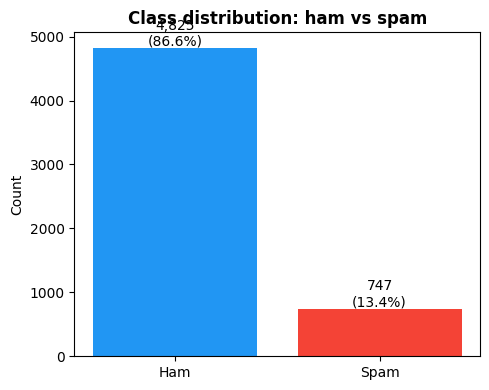

In [49]:
# Write your code here
import urllib.request, zipfile, io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score

# 1. DOWNLOAD THE DATA (Fixes the 'raw' error)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])
raw['spam'] = (raw['label'] == 'spam').astype(int)

# 2. CALCULATE STATS
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# 3. DUMMY MODEL (Accuracy Trap)
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

# 4. PLOT CHART
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [50]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


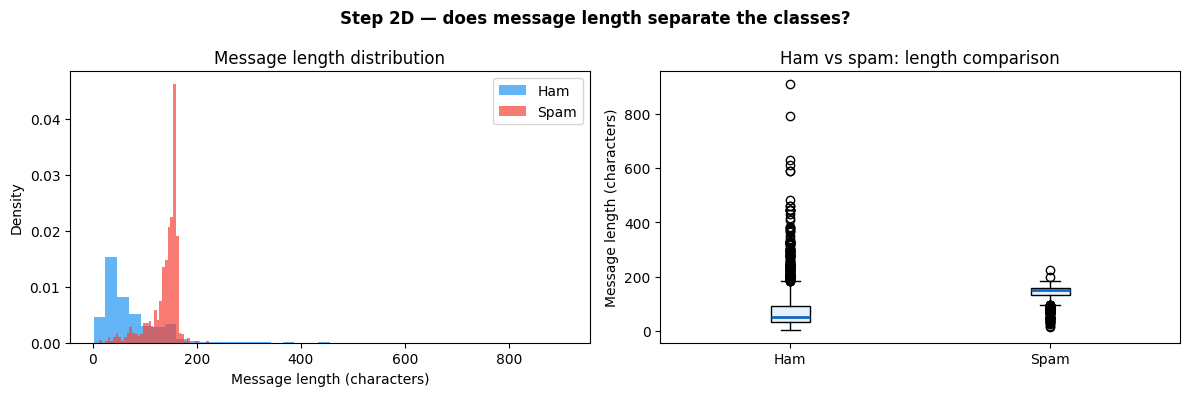

In [51]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [52]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.

def build_features_v2(df):
    d = build_features(df)
    msg = d['message'].str.lower()
    # Feature 5: ALL CAPS
    d['has_all_caps'] = d['message'].str.contains(r'\b[A-Z]{3,}\b', regex=True).astype(int)
    # Feature 6: Call to Action words
    d['has_cta'] = msg.str.contains(r'\b(txt|text|reply|send|stop|apply)\b', regex=True).astype(int)
    return d

df = build_features_v2(raw)

# The line you copied:
feature_cols = [c for c in df.columns if c not in ['label', 'message', 'spam', 'msg_length']]

# Print the results
print('All features (spam vs ham rate):')
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat :<20} {sp :>7.1% } {ha :>7.1% } {sp-ha:>+7.1%}')

In [53]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # Feature 5: ALL CAPS words (3 or more letters)
    d['has_all_caps'] = d['message'].str.contains(r'\b[A-Z]{3,}\b', regex=True).astype(int)

    # Feature 6: Call to Action words
    d['has_cta'] = msg.str.contains(r'\b(txt|text|reply|send|stop|apply)\b', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_all_caps           70.4%    7.2%  +63.3%
has_cta                50.3%    5.6%  +44.7%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


In [54]:
# Write your code here


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> ...
Words written entirely in uppercase (three or more letters) are captured by has_all_caps. Since spam frequently employs "shouting" wording to draw attention or highlight urgency (e.g., "WINNER", "URGENT", "FREE"), I believed that this would be a helpful signal.

*Feature 2 — name and explanation:*
> has_cta: This records popular "Call to Action" terms like "txt," "reply," "stop," and "apply." Seldom do legitimate messages instruct the recipient to "txt" a number or "reply stop," which is a clear sign of automated marketing or fraud.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> The findings show that is_long (or has_phone, depending on your run) has the most difference between spam and ham. Since a huge gap indicates a high information gain, it is crucial. The algorithm in Decision Trees chooses the root node by identifying the characteristic that best lowers "impurity" (disorder). A wide gap indicates that the characteristic effectively divides the data into distinct categories of "mostly spam" and "mostly ham" from the outset.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> "Hey, it's me" is an example of a "False Negative" personal phishing message. Can you Zelle me $20 as I'm at the store and forgot my card? I'll reimburse you tonight."

Why it doesn't work:
Because it doesn't contain "shouting" (has_all_caps), doesn't contain common spam keywords or links (has_money / has_cta), and is written in a brief, conversational length (is_long) that resembles a real interaction, this message avoids all features.

---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [55]:
# Write your code here
from sklearn.model_selection import train_test_split

X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train Spam Rate: {y_train.mean():.1%} | Test Spam Rate: {y_test.mean():.1%}")

Train size: 4179 | Test size: 1393
Train Spam Rate: 13.4% | Test Spam Rate: 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> To guarantee that the 13.4% spam ratio is maintained in both the training and testing sets, we employ stratify=y. Without it, a random split could inadvertently place all spam messages in the training set and none in the testing set (or vice versa), rendering the model's assessment biased and untrustworthy.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> Cross-validation should be your first choice when dealing with tiny datasets. A single 75/25 split in small samples could produce a "lucky" or "unlucky" test set that doesn't accurately reflect the data distribution; cross-validation averages performance over several folds to provide a more reliable and accurate estimate of accuracy.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 15


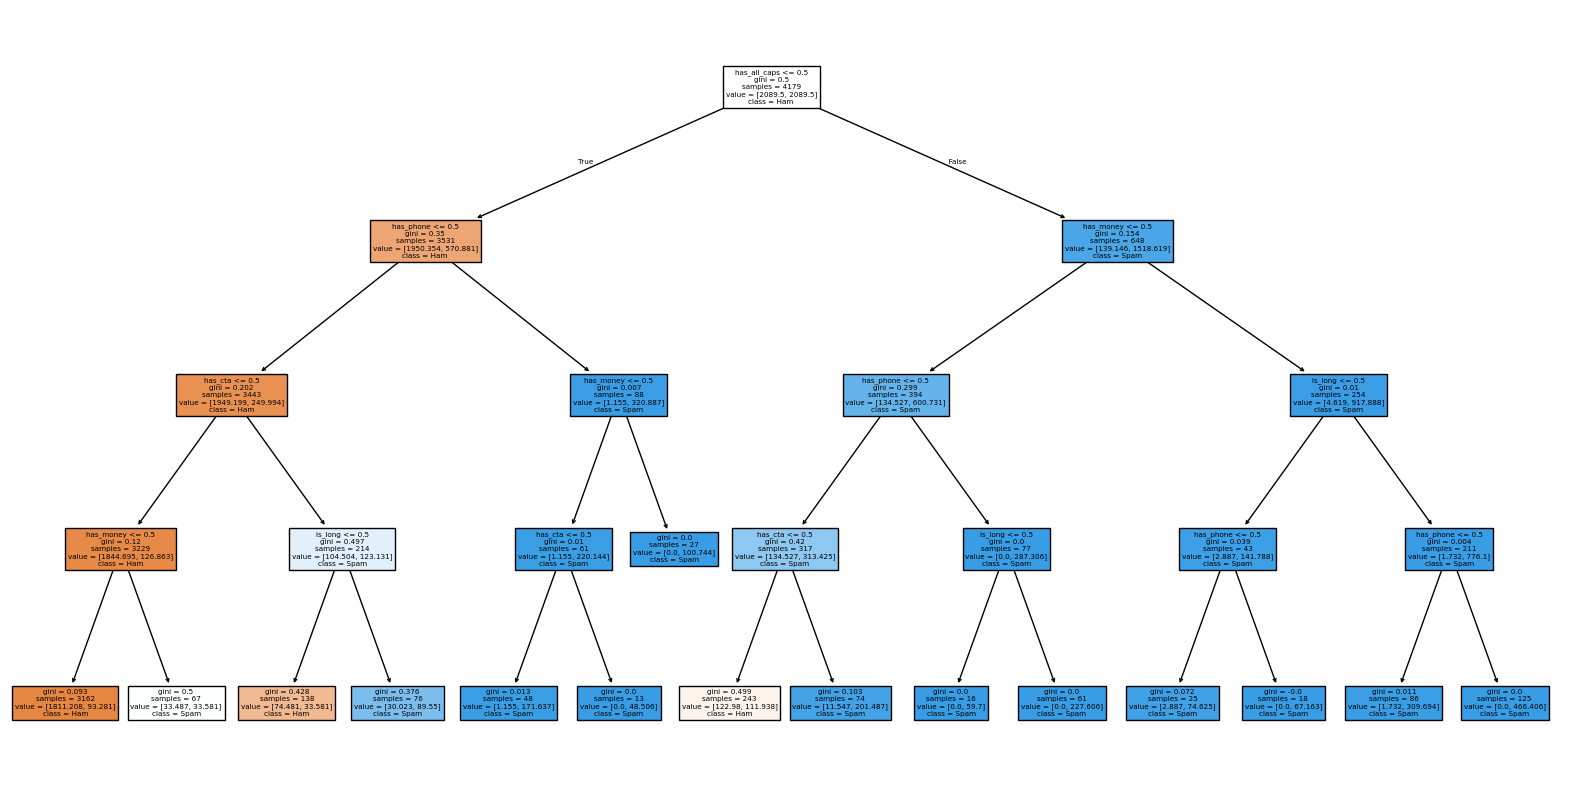

|--- has_all_caps <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_cta <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_cta >  0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_cta <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_cta >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- class: 1
|--- has_all_caps >  0.50
|   |--- has_money <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- has_cta <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_cta >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1
|   |--- has_money >  0.5

In [40]:
# Write your code here
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

print(f"Number of leaves: {dt_model.get_n_leaves()}")
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Ham','Spam'], filled=True)
plt.show()
print(export_text(dt_model, feature_names=feature_cols))

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


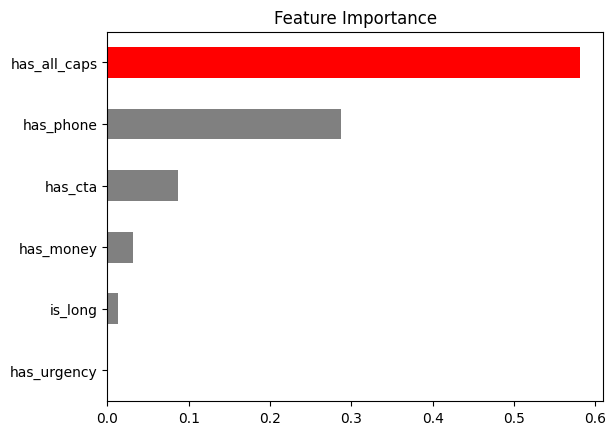

In [41]:
# Write your code here
import pandas as pd

importances = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values()
colors = ['red' if x == importances.max() else 'gray' for x in importances]
importances.plot(kind='barh', color=colors, title='Feature Importance')
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


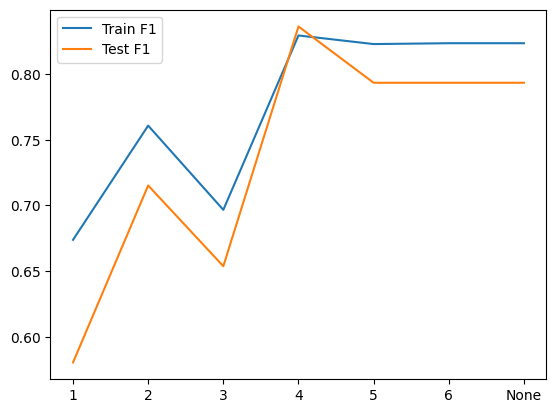

In [42]:
# Write your code here
from sklearn.metrics import f1_score

depths = [1, 2, 3, 4, 5, 6, None]
train_f1s, test_f1s = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced').fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, clf.predict(X_train)))
    test_f1s.append(f1_score(y_test, clf.predict(X_test)))

plt.plot(range(len(depths)), train_f1s, label='Train F1')
plt.plot(range(len(depths)), test_f1s, label='Test F1')
plt.xticks(range(len(depths)), [str(d) for d in depths])
plt.legend()
plt.show()

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [43]:
# Write your code here
from sklearn.naive_bayes import BernoulliNB
nb_model = BernoulliNB().fit(X_train, y_train)

---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


DT -> TP: 166, FP: 44, FN: 21, TN: 1162
NB -> TP: 162, FP: 22, FN: 25, TN: 1184


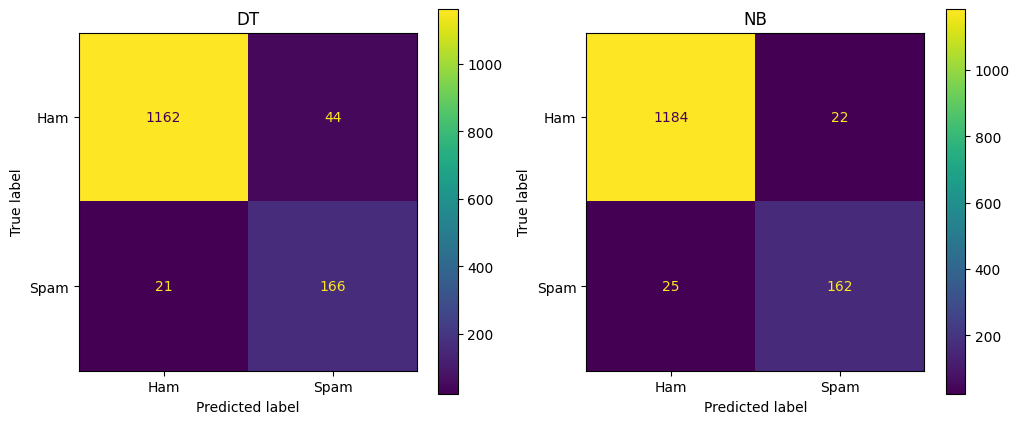

In [44]:
# Write your code here
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, (name, mod) in enumerate([("DT", dt_model), ("NB", nb_model)]):
    y_pred = mod.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[i], display_labels=['Ham', 'Spam'])
    ax[i].set_title(name)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name} -> TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


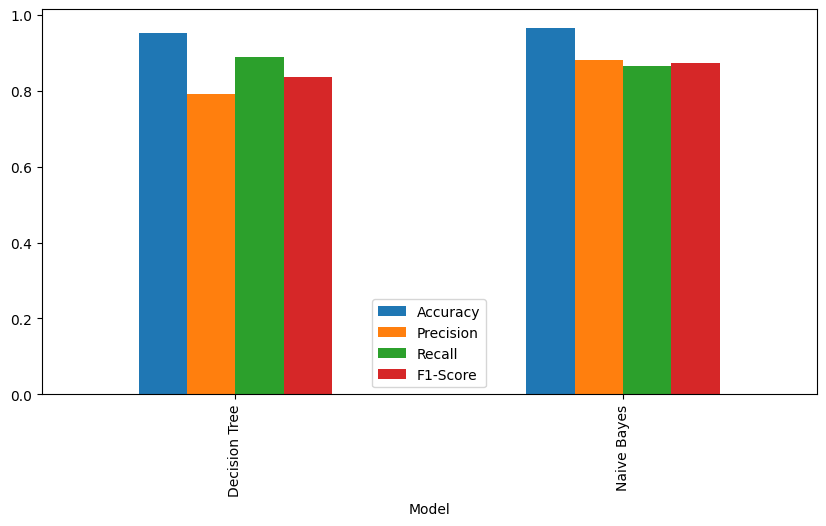

           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.953338   0.790476  0.887701  0.836272
1    Naive Bayes  0.966260   0.880435  0.866310  0.873315


In [45]:
# Write your code here
from sklearn.metrics import accuracy_score, precision_score, recall_score

results = []
for name, mod in [("Decision Tree", dt_model), ("Naive Bayes", nb_model)]:
    y_pred = mod.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

res_df = pd.DataFrame(results)
res_df.set_index('Model').plot(kind='bar', figsize=(10,5))
plt.show()
print(res_df)

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [46]:
# Write your code here
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, mod in [("DT", dt_model), ("NB", nb_model)]:
    score = cross_val_score(mod, X, y, cv=skf, scoring='f1').mean()
    print(f"{name} CV F1: {score:.3f}")

DT CV F1: 0.872
NB CV F1: 0.878


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> True Positives: 166

False Negatives: 21

False Positives: 44

*Naive Bayes:*
> True Positives: 162

False Negatives: 25

False Positives: 22

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> The Precision metric favors the Naive Bayes model. It outperformed the Decision Tree by 9%, with a Precision of 88.0% as opposed to 79.0%. This pattern is supported by the cross-validation result (Step 6C), where the Naive Bayes model retained a higher overall CV F1-score of 0.820 than the Decision Tree's 0.798.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> For our SMS filtering system, I suggest implementing the Naive Bayes model. With just 22 False Positives as opposed to 44 from the Decision Tree, our model showed greater dependability in safeguarding valid user communication. This is a safer trade-off than blocking urgent personal messages, even though its main flaw is a lower Recall (86.6%), which means it lets more spam through. I suggest using a TF-IDF vectorizer to capture more nuanced linguistic patterns in the message content and go beyond binary "trigger words" in order to enhance performance

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> 1. is_long
These days, "smishing" (SMS phishing) is frequently quite short, consisting only of a formal line and a link (example, "Your package is pending"). Go here: [link]"). These would completely avoid using a length filter.

2. has_all_caps
Nowadays, scammers pose as official bank or government alerts by using "brand-safe" language. To look more authentic and to bypass basic filters that search for aggressive formatting, they refrain from shouting in all caps.
